# Simulate Populations with Spontaneus Birth
## Part 3

Previously we simulated the growth of our population, let's use algebra and what we know about the properties of the population of protocells (and the like) to find an analytical solution.

## Population Equilibrium Equation

The population is governed by the balance between the birth rate $B$ and the death rate $D$, which can be calculated as the death chance $d$ times the current population $P$, such that we have the equation:

$$D=Pd$$

The population is stable when $B=D$. To determine the population at which the death rate and the birth rate are in equilibrium, we can solve this equation for $P$:

$$
\begin{equation*}
\begin{aligned}
B&=D &&\text{Substitute Pd for D} \\
B&=Pd &&\text{Divide out d} \\
P&=\frac{B}{d} \\
\end{aligned}
\end{equation*}
$$

In the simulation, we set `birth_rate = 1` and `death_chance = 0.1`. Let's plug these into the equation and determine if our observation that the population appears to level off at 10 was correct.


$$
\begin{aligned}
P&=\frac{1}{0.1} \\
P&=10 \\
\end{aligned}
$$

As you can see, in the environment we have simulated, the death rate and the birth rate are at equilibrium when the population is 10.

## Change in Population Function

If we know the current value of $B$ and $D$, then the population change $\Delta P$ is their difference.

$$
\begin{equation*}
\begin{aligned}
\Delta P &= B-D &&\text{Substitute Pd for D}\\
\Delta P &= B-Pd \\
\end{aligned}
\end{equation*}
$$

If we hold B and d constant, we have the function $f(P)$.

$$f(P)=B-Pd$$

This function gives us the expected change of the population $\Delta P$ at the next time step, given the current population $P$.

Let's graph the function.

In [12]:
# Import required modules
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [13]:
def delta_p(population, birth_rate, death_chance):
    """ Calculate the expected change in population with spontaneus brith_rate and a known death_rate"""

    return (-(population * death_chance) + birth_rate)

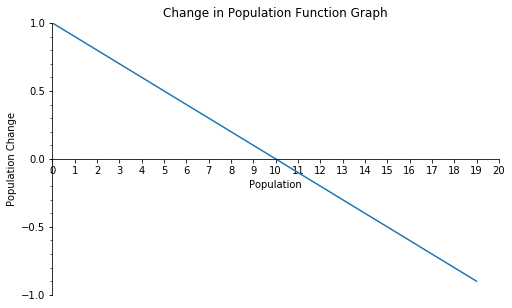

In [15]:
# Set population parameters
domain = 20
birth_rate = 1
death_chance = 0.1

# Generate plot data for the specified population domain
population_change = [delta_p(p, birth_rate, death_chance) for p in range(domain)]

# Set up plot
fig, ax = plt.subplots(figsize=(8,5))
ax.set(
    title=f"Change in Population Function Graph",
    xlabel="Population",
    ylabel="Population Change",
    xlim=(0, domain)
)

# Set the axis tick marks and labels
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.yaxis.set_major_locator(ticker.MultipleLocator(.5))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(.1))
ax.set_ylim(-1, 1)

# Convert the graph spines so that they are centered on 0, 0 and don't show top or right boundaries
ax.spines['left'].set_position(('data', 0))
ax.spines['bottom'].set_position(('data', 0))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# plot data
ax.plot(population_change)
plt.show()

## Conclusion

As you can see, the graph of $\Delta P$ passes through the equilibrium point 10. Furthermore, when the current population is below 10, the change is expected to be positve, whereas when the population is above 10, the change is expected to be negative.

This makes sense, each protocell has the same chance of dying at the end of each time step. If there are more protocells, there is a greater chance one or more will die, causing the population to shrink. On the other hand, if there are less protocells, the chance that one or more will die is less, causing the popualtion to grow. When the `birth_rate` $B$ is 1 and the `death_chance` $D$ is 0.1, this relationship balances on a population of 10, since we would expect $0.1*10=1$ protocells to die at the end of the period, being replaced by exactly 1 new protocell such that the overall change in population is expected to be 0.

Before fleshing out our findings into a complete analytical model, let's look at the 'age' of protocells in the population when they expire. In the next section, we will update the `environment` class with an additional variable, `mortuary`. 